# ViT Transfer Learning - DeiT Model
## Setup Instructions

**Choose ONE of the following setup cells based on your environment:**
- **Running on Google Colab?** → Run the "Colab Setup" cell below
- **Running locally?** → Run the "Local Setup" cell below

Then proceed with the rest of the notebook.

In [ ]:
# COLAB SETUP - Run this cell ONLY if on Google Colab

from google.colab import drive
drive.mount('/content/drive')

# Navigate to project directory
%cd /content/drive/MyDrive/DeepFakeDetector

# Install required packages
!pip install -q timm torch torchvision

print("Colab setup complete")

In [ ]:
# LOCAL SETUP - Run this cell ONLY if running locally

import sys
import os
from pathlib import Path

# Add project root to path for imports
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print("Local setup complete")

---
### ⚠️ DATA PATHS NOTE

**The data loading cells below use HARDCODED PATHS.**

If running **locally**, you will need to manually update the data paths in the cells below from:
```python
"/content/drive/MyDrive/DeepFakeDetector/datasets/OpenFake/train"
```

To:
```python
"datasets/OpenFake/train"  # or your local path
```

Look for cells that set `train_dir`, `test_dir`, or similar variables.

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
GDRIVE_DATA_DIR = "/content/drive/MyDrive/"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
from PIL import Image
import os

In [ ]:
!pip install datasets==3.6.0
!pip install modelscope==1.28.0

**IMPORTING DRAGON INTO DRIVE**

In [ ]:
import os
from tqdm import tqdm
from datasets import load_dataset

def import_dragon(size="ExtraSmall", max_train=None, max_test=None):
    """
    Import DRAGON dataset images into Google Drive.

    Output structure:
        datasets/Dragon/
            train/
            test/
    """

    base_dir = os.path.join(GDRIVE_DATA_DIR, "datasets", "Dragon")
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    print(f"Loading DRAGON ({size})...")
    ds = load_dataset("lesc-unifi/dragon", size)

    def save_split(split, out_dir, max_images):
        for i, sample in enumerate(tqdm(split)):
            if max_images is not None and i >= max_images:
                break

            image = sample["png"]
            if image.mode != "RGB":
                image = image.convert("RGB")

            image.save(os.path.join(out_dir, f"{i:07d}.jpg"))

    if "train" in ds:
        save_split(ds["train"], train_dir, max_train)

    if "test" in ds:
        save_split(ds["test"], test_dir, max_test)

    print(f"Done. Saved to {base_dir}")


In [ ]:
import_dragon(size="ExtraSmall", max_train=100, max_test=50)


Loading DRAGON (ExtraSmall)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train/xs/dragon_train_xs.tar:   0%|          | 0.00/326M [00:00<?, ?B/s]

test/dragon_test_00.tar:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

  5%|▌         | 50/1000 [00:02<00:40, 23.36it/s]

Done. Saved to /content/drive/MyDrive/datasets/Dragon


In [ ]:
# downloading already taken care of, saved in datasets folder in drive and mounted above

**GENERATE DATALOADER AND TESTLOADER - set for Wildfake rn**

In [ ]:
# import os
# import random

# # train_dir = '/content/drive/MyDrive/datasets/OpenFake/train'
# train_dir = '/content/drive/MyDrive/datasets/wildfake_2k_split/train'
# real_dir = os.path.join(train_dir, 'real')
# fake_dir = os.path.join(train_dir, 'fake')

# num_images = 1500

# real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
# fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

# # Ensure that we don't try to sample more images than available
# selected_real_images = random.sample(real_images, min(num_images, len(real_images)))
# selected_fake_images = random.sample(fake_images, min(num_images, len(fake_images)))

# # Combine them into a list of selected images with their labels
# selected_images = selected_real_images + selected_fake_images
# labels = [0] * len(selected_real_images) + [1] * len(selected_fake_images)

# print(f"Selected {len(selected_real_images)} real images and {len(selected_fake_images)} fake images.")

Selected 800 real images and 800 fake images.


In [ ]:
# import torch
# from torchvision import transforms
# from torch.utils.data import Dataset, DataLoader
# from PIL import Image

# class OpenFakeDataset(Dataset):
#     def __init__(self, image_paths, labels, transform=None):
#         self.image_paths = image_paths
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         image = Image.open(img_path).convert("RGB")
#         label = self.labels[idx]

#         if self.transform:
#             image = self.transform(image)

#         return image, label

# # Image transformations
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),    # Resize to match ViT's input size
#     transforms.ToTensor(),            # Convert image to tensor
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats that the ViT was trained on
# ])


# dataset = OpenFakeDataset(selected_images, labels, transform=transform)
# dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# test_dataset = OpenFakeDataset(test_dir, transform=transform)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate)


NameError: name 'OpenFakeTestDataset' is not defined

**PREPROCESS FUNCTIONS + GENERATE TEST/TRAIN LOADERS**

In [ ]:
# ============================
# Full Preprocessing + Dataset
# ============================

from dataclasses import dataclass
from typing import Dict, List, Tuple
from pathlib import Path
import os
import numpy as np
from PIL import Image, ImageOps

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import os
import random

# -----------------------------
# Normalization constants
# -----------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
CLIP_MEAN     = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD      = (0.26862954, 0.26130258, 0.27577711)

@dataclass
class PreprocessConfig:
    vit_size: int = 224            # ViT input size
    cnn_patch: int = 224           # patch size for CNN 'spatial expert'
    patch_stride: float = 0.5      # overlap fraction (0.5 = 50%)
    normalize: str = "imagenet"    # "imagenet" or "clip"
    ycbcr_for_fft: bool = True
    windowing: str = "hann"
    preserve_exif_orientation: bool = True
    max_long_side: int = 4096

def resize_keep_ar(img: Image.Image, long_side: int) -> Image.Image:
    """Downscale large images while preserving aspect ratio."""
    w, h = img.size
    m = max(w, h)
    if m <= long_side:
        return img.copy()
    scale = long_side / float(m)
    new_size = (int(round(w * scale)), int(round(h * scale)))
    return img.resize(new_size, resample=Image.BICUBIC, reducing_gap=2.0)

def _norm_transform(scheme: str):
    if scheme.lower() == "clip":
        return T.Normalize(CLIP_MEAN, CLIP_STD)
    return T.Normalize(IMAGENET_MEAN, IMAGENET_STD)

def make_vit_tensor(img: Image.Image, size: int, scheme: str):
    # resize shortest side, center crop, to tensor, normalize
    t = T.Compose([
        T.Resize(size, interpolation=T.InterpolationMode.BICUBIC, antialias=True),
        T.CenterCrop((size, size)),
        T.ToTensor(),
        _norm_transform(scheme),
    ])
    return t(img)

def extract_patches(img: Image.Image, patch: int, stride_ratio: float) -> Tuple[List[Image.Image], List[int], List[int]]:
    """Sliding-window patch extraction with overlap."""
    W, H = img.size
    stride = max(1, int(round(patch * stride_ratio)))
    xs = list(range(0, max(W - patch, 0) + 1, stride))
    ys = list(range(0, max(H - patch, 0) + 1, stride))
    if not xs: xs = [0]
    if not ys: ys = [0]
    patches = []
    for y in ys:
        for x in xs:
            crop = img.crop((x, y, x + patch, y + patch))
            if crop.size != (patch, patch):
                pad = Image.new("RGB", (patch, patch))
                pad.paste(crop, (0, 0))
                crop = pad
            patches.append(crop)
    return patches, xs, ys

def ycbcr_channels(img: Image.Image):
    ycbcr = img.convert("YCbCr")
    Y, Cb, Cr = ycbcr.split()
    return Y, Cb, Cr

def _window(arr: np.ndarray, kind: str):
    h, w = arr.shape[:2]
    if kind == "hann":
        wy = np.hanning(h)[:, None]
        wx = np.hanning(w)[None, :]
        return wy * wx
    if kind == "hamming":
        wy = np.hamming(h)[:, None]
        wx = np.hamming(w)[None, :]
        return wy * wx
    return np.ones((h, w), dtype=arr.dtype)

def fft_log_magnitude(gray_img: Image.Image, window: str = "hann") -> Image.Image:
    """Compute log-magnitude FFT spectrum as a single-channel image in [0,255]."""
    arr = np.array(gray_img).astype(np.float32) / 255.0
    win = _window(arr, window)
    F = np.fft.fft2(arr * win)
    Fshift = np.fft.fftshift(F)
    mag = np.log1p(np.abs(Fshift))
    mag = (mag - mag.mean()) / (mag.std() + 1e-6)
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-6)
    return Image.fromarray((mag * 255).astype(np.uint8))

def patches_to_tensor(patches: List[Image.Image], scheme: str):
    t = T.Compose([
        T.ToTensor(),
        _norm_transform(scheme),
    ])
    return torch.stack([t(p) for p in patches], dim=0)

def preprocess_all(path: str, cfg: PreprocessConfig = PreprocessConfig()) -> Dict:
    """Full pipeline for one image: returns vit, cnn_patches, fft_tensor, meta."""
    img = Image.open(path)
    if cfg.preserve_exif_orientation:
        img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")

    # resize if huge
    img = resize_keep_ar(img, cfg.max_long_side)

    # ViT input
    vit_tensor = make_vit_tensor(img, cfg.vit_size, "imagenet")

    # CNN patches
    patches, xs, ys = extract_patches(img, cfg.cnn_patch, cfg.patch_stride)
    cnn_patches = patches_to_tensor(patches, "imagenet")

    # FFT on luminance
    Y, Cb, Cr = ycbcr_channels(img.resize((cfg.cnn_patch, cfg.cnn_patch), Image.BICUBIC))
    fft_img = fft_log_magnitude(Y, cfg.windowing)
    fft_tensor = T.ToTensor()(fft_img)  # [1, H, W]

    return {
        "vit": vit_tensor,
        "cnn_patches": cnn_patches,
        "fft_tensor": fft_tensor,
        "meta": {
            "grid_x": xs,
            "grid_y": ys,
            "patch_size": cfg.cnn_patch,
            "stride_ratio": cfg.patch_stride,
        }
    }

# -----------------------------
# Dataset + collate (old style)
# -----------------------------

VALID_EXT = {".jpg", ".jpeg", ".png", ".webp"}

class PreprocDataset(Dataset):
    """
    Loads files from root/{real,fake}, calls preprocess_all(path),
    and attaches label: real=0, fake=1.
    """
class PreprocDataset(Dataset):
    def __init__(self, root: str | Path, max_images: int | None = None):
        self.items = []
        root = Path(root)

        if max_images is not None:
            max_per_class = max_images // 2
        else:
            max_per_class = None

        for y, cls in enumerate(["real", "fake"]):
            d = root / cls
            if not d.exists():
                continue

            files = [f for f in d.iterdir() if f.suffix.lower() in VALID_EXT]

            if max_per_class is not None:
                files = random.sample(files, min(len(files), max_per_class))

            for f in files:
                self.items.append((str(f), y))

        random.shuffle(self.items)

        if not self.items:
            raise RuntimeError(f"No images found under {root}/real or {root}/fake")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx) -> Dict:
        path, y = self.items[idx]
        out = preprocess_all(path)   # vit, cnn_patches, fft_tensor, meta
        out["label"] = y             # numeric label
        return out

def collate(batch: List[Dict]) -> Dict:
    """
    Returns a dict ready for models:
      - vit:    [B,3,S,S]
      - fft:    [B,1,P,P]
      - patches: list of [N_i,3,P,P]
      - labels: [B]
      - meta:   list of metadata dicts
    """
    labels = torch.tensor([b["label"] for b in batch]).long()
    vit = torch.stack([b["vit"] for b in batch])                 # [B,3,S,S]
    fft = torch.stack([b["fft_tensor"] for b in batch])          # [B,1,P,P]
    patches = [b["cnn_patches"] for b in batch]                  # list of [N_i,3,P,P]
    meta = [b["meta"] for b in batch]
    return {"vit": vit, "fft": fft, "patches": patches, "labels": labels, "meta": meta}

# -----------------------------
# Build train & test loaders
# -----------------------------

# train_dir = "/content/drive/MyDrive/datasets/OpenFake/train"
# test_dir  = "/content/drive/MyDrive/datasets/OpenFake/test"
train_dir = "/content/drive/MyDrive/datasets/wildfake_2k_split/train"
test_dir  = "/content/drive/MyDrive/datasets/wildfake_2k_split/test"

# Use max_images=None for full set, or e.g. max_images=1000 to limit
train_dataset = PreprocDataset(train_dir, max_images=2000)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate,
)

test_dataset = PreprocDataset(test_dir, max_images=1000)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")


Train samples: 1600
Test samples:  400


**CREATE MODEL**

In [ ]:
from timm import create_model
import torch.nn as nn

model = create_model("deit_small_patch16_224", pretrained=True)

# Get the number of input features to the final layer
num_ftrs = model.num_features

# Create a new classification head with 2 output classes (real, fake)
model.head = nn.Linear(num_ftrs, 2)

model.eval()
print(model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device selected:", device)

if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

model = model.to(device)

x = torch.randn(1, 3, 224, 224).to(device)
print("Tensor is on:", x.device)


Device selected: cuda
GPU Name: NVIDIA L4
Tensor is on: cuda:0


Unfreezing entire ViT backbone...

=== Training UNFROZEN backbone (fine-tuning) ===

Epoch 1/2


100%|██████████| 125/125 [27:04<00:00, 13.00s/it]


Fine-Tune Loss: 0.6503, Acc: 61.60%

Epoch 2/2


100%|██████████| 125/125 [01:41<00:00,  1.24it/s]


Fine-Tune Loss: 0.3696, Acc: 86.15%

=== Evaluating fine-tuned model ===


100%|██████████| 62/62 [12:57<00:00, 12.53s/it]


=== Fine-Tuned Results ===
Accuracy: 78.32%
Sensitivity (Fake TPR): 0.82
Specificity (Fake TNR): 0.74
PPV (Fake Precision): 0.77
NPV: 0.80
Average Loss: 0.4571

Classification Report (0=Real, 1=Fake):
              precision    recall  f1-score   support

           0     0.8009    0.7406    0.7696       478
           1     0.7687    0.8240    0.7954       500

    accuracy                         0.7832       978
   macro avg     0.7848    0.7823    0.7825       978
weighted avg     0.7844    0.7832    0.7828       978



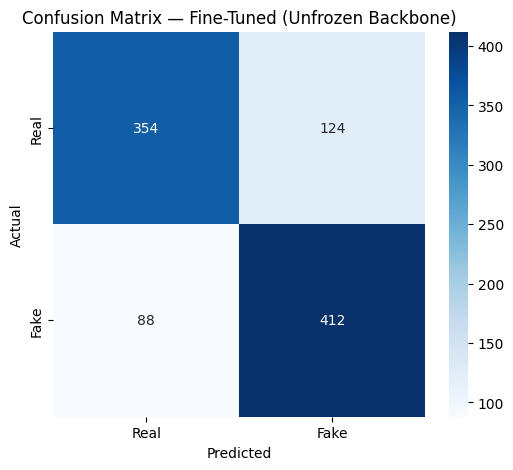

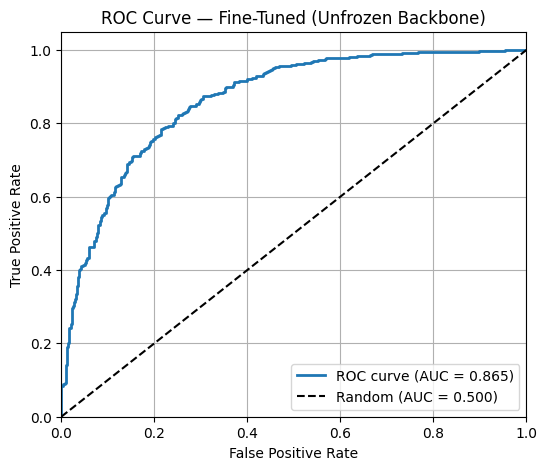

In [ ]:
#######################
# UNFROZEN BACKBONE
#######################

import torch
from torch import nn
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# Unfreeze backbone
# =====================
print("Unfreezing entire ViT backbone...")
for param in model.parameters():
    param.requires_grad = True

# ====================================
# Define optimizer for full model
# ====================================
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

fine_tune_epochs = 2
model.to(device)

# =============================
# Fine-tuning training loop
# =============================
print("\n=== Training UNFROZEN backbone (fine-tuning) ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    # NOTE: use train_loader (not dataloader)
    for batch in tqdm(train_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / max(total_samples, 1)
    epoch_acc = running_correct / max(total_samples, 1) * 100
    print(f"Fine-Tune Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

# ============================
# Evaluate fine-tuned model
# ============================
print("\n=== Evaluating fine-tuned model ===")

model.eval()
all_labels_ft = []
all_preds_ft = []
all_probs_ft = []
eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        # class 1 prob (your setup: real=0, fake=1)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels_ft.extend(labels.cpu().numpy())
        all_preds_ft.extend(preds.cpu().numpy())
        all_probs_ft.extend(probs.cpu().numpy())

avg_loss = eval_loss / max(total_samples, 1)
acc = accuracy_score(all_labels_ft, all_preds_ft)

# Confusion matrix: rows=true [0=Real,1=Fake], cols=pred [0=Real,1=Fake]
cm = confusion_matrix(all_labels_ft, all_preds_ft)
tn, fp, fn, tp = cm.ravel()

# Metrics treating "Fake" (label=1) as the positive class
sensitivity = tp / (tp + fn + 1e-8)  # TPR for fake
specificity = tn / (tn + fp + 1e-8)  # TNR for fake (i.e., correctly real)
ppv = tp / (tp + fp + 1e-8)          # precision for fake
npv = tn / (tn + fn + 1e-8)

print("\n=== Fine-Tuned Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity (Fake TPR): {sensitivity:.2f}")
print(f"Specificity (Fake TNR): {specificity:.2f}")
print(f"PPV (Fake Precision): {ppv:.2f}")
print(f"NPV: {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")
print("Classification Report (0=Real, 1=Fake):")
print(classification_report(all_labels_ft, all_preds_ft, digits=4))

# ====================
# Confusion Matrix
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned (Unfrozen Backbone)")
plt.show()

# ============
# ROC Curve
# ============
fpr_ft, tpr_ft, _ = roc_curve(all_labels_ft, all_probs_ft)  # positive class = 1 (Fake)
roc_auc_ft = auc(fpr_ft, tpr_ft)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ft, tpr_ft, label=f"ROC curve (AUC = {roc_auc_ft:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned (Unfrozen Backbone)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
checkpoint = {
    "model": model.state_dict(),                       # entire model object
    "optimizer_state": optimizer.state_dict(),
    "epoch": epoch
}

torch.save(checkpoint, "/content/drive/MyDrive/DeepfakeDetectionModels/vit_transfer_baseline_deit_unfrozen_backbone_78%.pth")
print("Saved full model checkpoint.")


Saved full model checkpoint.




Verifying Labels to Debug

In [ ]:
import numpy as np
print("Unique preds:", np.unique(all_preds_ft, return_counts=True))
print("Unique labels:", np.unique(all_labels_ft, return_counts=True))


Unique preds: (array([0, 1]), array([504, 496]))
Unique labels: (array([0, 1]), array([478, 522]))


In [ ]:
from collections import Counter
print("Train label counts:", Counter([y for _, y in train_dataset.items]))
print("Test label counts:", Counter([y for _, y in test_dataset.items]))


Train label counts: Counter({0: 200, 1: 200})
Test label counts: Counter({1: 522, 0: 478})



**Fine-Tune #3 - Distilled Deit Model Training/Testing with OpenFake**

In [ ]:
# ============================================================
# DeiT-Base Distilled (timm) + Custom 2-class head
# ============================================================

from timm import create_model
import torch
import torch.nn as nn
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------
# Model
# ---------
model = create_model("deit_base_distilled_patch16_224", pretrained=True)
num_ftrs = model.num_features

# Custom classification head (2 classes: 0=Real, 1=Fake)
head = nn.Sequential(
    nn.LayerNorm(num_ftrs),
    nn.Linear(num_ftrs, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, 2),
)

# Replace BOTH heads
model.head = head
if hasattr(model, "head_dist"):
    model.head_dist = nn.Sequential(
        nn.LayerNorm(num_ftrs),
        nn.Linear(num_ftrs, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, 2),
    )

model.to(device)

# ---------
# Unfreeze all params
# ---------
for p in model.parameters():
    p.requires_grad = True

# ---------
# Discriminative LR (backbone smaller LR, head larger LR)
# ---------
backbone_params, head_params = [], []
for name, p in model.named_parameters():
    if name.startswith("head") or name.startswith("head_dist"):
        head_params.append(p)
    else:
        backbone_params.append(p)

optimizer = AdamW(
    [
        {"params": backbone_params, "lr": 2e-5},
        {"params": head_params,     "lr": 5e-5},
    ],
    weight_decay=1e-4,
)

criterion = nn.CrossEntropyLoss()
fine_tune_epochs = 4


Using device: cuda


In [ ]:
## Training new model

print("\n=== Fine-Tuning DeiT-Base Distilled ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    for batch in tqdm(train_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # Distilled DeiT may return (logits, dist_logits) in training
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # or (outputs[0] + outputs[1]) / 2

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples * 100
    print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%")



=== Fine-Tuning DeiT-Base Distilled ===

Epoch 1/4


100%|██████████| 125/125 [01:50<00:00,  1.14it/s]


Train Loss: 0.5481, Train Acc: 71.40%

Epoch 2/4


100%|██████████| 125/125 [01:50<00:00,  1.13it/s]


Train Loss: 0.2624, Train Acc: 89.25%

Epoch 3/4


100%|██████████| 125/125 [01:50<00:00,  1.13it/s]


Train Loss: 0.1015, Train Acc: 96.35%

Epoch 4/4


100%|██████████| 125/125 [01:50<00:00,  1.14it/s]

Train Loss: 0.0276, Train Acc: 99.20%


In [ ]:
## Evaluation

print("\n=== Evaluating Fine-Tuned DeiT-Base Distilled ===")

model.eval()
all_labels = []
all_preds = []
all_probs = []
eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)

        # Handle possible (logits, dist_logits) in eval too
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

avg_loss = eval_loss / total_samples
acc = accuracy_score(all_labels, all_preds)

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
ppv = tp / (tp + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print("\n=== Fine-Tuned Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"PPV: {ppv:.2f}")
print(f"NPV: {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))


=== Evaluating Fine-Tuned DeiT-Base Distilled ===


100%|██████████| 62/62 [00:47<00:00,  1.32it/s]


=== Fine-Tuned Results ===
Accuracy: 85.58%
Sensitivity: 0.84
Specificity: 0.87
PPV: 0.87
NPV: 0.84
Average Loss: 0.6027

Classification Report:
              precision    recall  f1-score   support

           0     0.8390    0.8724    0.8554       478
           1     0.8732    0.8400    0.8563       500

    accuracy                         0.8558       978
   macro avg     0.8561    0.8562    0.8558       978
weighted avg     0.8565    0.8558    0.8558       978



In [ ]:
checkpoint = {
    "model": model.state_dict(),                       # entire model object
    "optimizer_state": optimizer.state_dict(),
    "epoch": epoch
}

torch.save(checkpoint, "/content/drive/MyDrive/DeepfakeDetectionModels/vit_transfer_baseline_deit_distlled_86%.pth")
print("Saved full model checkpoint.")


Saved full model checkpoint.


**Distilled Deit Model Testing on WildFake**

Create Model, Load Checkpoint (Openfake-trained Distilled Deit)

In [ ]:
# ============================================================
# Load DeiT-Base Distilled model from checkpoint (EVAL ONLY)
# ============================================================

from timm import create_model
import torch
import torch.nn as nn

# ---------
# Device
# ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------
# Recreate model architecture (must match training)
# ---------
model = create_model(
    "deit_base_distilled_patch16_224",
    pretrained=False
)

num_ftrs = model.num_features

# Custom classification head (2 classes)
model.head = nn.Sequential(
    nn.LayerNorm(num_ftrs),
    nn.Linear(num_ftrs, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, 2),
)

# Distillation head (must also be recreated)
if hasattr(model, "head_dist"):
    model.head_dist = nn.Sequential(
        nn.LayerNorm(num_ftrs),
        nn.Linear(num_ftrs, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, 2),
    )

# ---------
# Load checkpoint
# ---------
ckpt_path = "/content/drive/MyDrive/DeepfakeDetectionModels/vit_transfer_baseline_deit_distlled_openfake_86%.pth"

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model"])

# ---------
# Ready for evaluation
# ---------
model.to(device)
model.eval()


Using device: cuda


VisionTransformerDistilled(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inpl

Evaluate on Wildfake Test images


=== Evaluating fine-tuned model ===


100%|██████████| 25/25 [00:05<00:00,  4.45it/s]


=== Results ===
Accuracy: 72.00%
F1 (Fake=positive): 0.6606
AUC: 0.7433
Sensitivity (Fake TPR): 0.5450
Specificity (Fake TNR): 0.8950
PPV (Fake Precision): 0.8385
NPV: 0.6630
Average Loss: 1.0568

Classification Report (0=Real, 1=Fake):
              precision    recall  f1-score   support

           0     0.6630    0.8950    0.7617       200
           1     0.8385    0.5450    0.6606       200

    accuracy                         0.7200       400
   macro avg     0.7507    0.7200    0.7112       400
weighted avg     0.7507    0.7200    0.7112       400



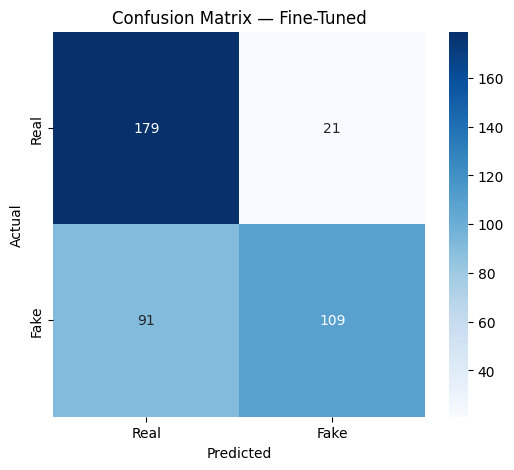

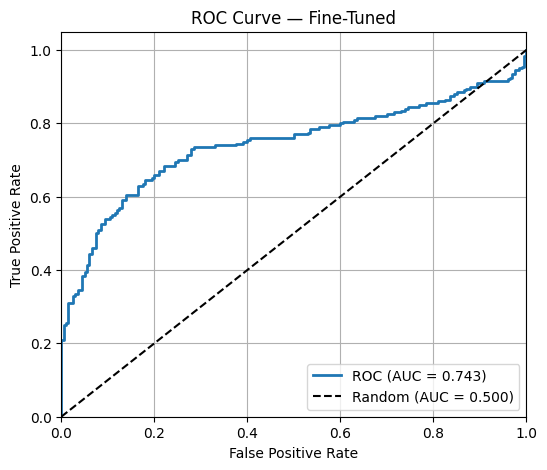

In [ ]:
# ============================
# Full Evaluation Script
# ============================

import torch
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score,
)

# ----
# Make sure criterion exists
# ----
criterion = torch.nn.CrossEntropyLoss()

print("\n=== Evaluating fine-tuned model ===")
model.eval()

all_labels = []
all_preds = []
all_probs = []

eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)      # [B,3,224,224]
        labels = batch["labels"].to(device)   # [B]

        outputs = model(images)

        # DeiT distilled may output (logits, dist_logits) in some configs
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]   # P(class=1=Fake)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

# ----
# Metrics
# ----
avg_loss = eval_loss / max(total_samples, 1)
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds)  # positive class defaults to 1 in binary case

cm = confusion_matrix(all_labels, all_preds)  # rows=true, cols=pred
tn, fp, fn, tp = cm.ravel()

# Treat Fake (1) as positive
sensitivity = tp / (tp + fn + 1e-8)  # TPR
specificity = tn / (tn + fp + 1e-8)  # TNR
ppv = tp / (tp + fp + 1e-8)          # precision
npv = tn / (tn + fn + 1e-8)

# ROC + AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)  # positive class=1
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n=== Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"F1 (Fake=positive): {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print(f"Sensitivity (Fake TPR): {sensitivity:.4f}")
print(f"Specificity (Fake TNR): {specificity:.4f}")
print(f"PPV (Fake Precision): {ppv:.4f}")
print(f"NPV: {npv:.4f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report (0=Real, 1=Fake):")
print(classification_report(all_labels, all_preds, digits=4))

# ====================
# Confusion Matrix Plot
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned")
plt.show()

# ============
# ROC Curve Plot
# ============
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# ============================================================
# Save DeiT distilled artifacts to Google Drive (models/ base)
# ============================================================

from google.colab import drive
from pathlib import Path
import json
import torch

# 1. Mount Google Drive (run once per session)
drive.mount("/content/drive")

# 2. Base models directory in Google Drive
OUT_DIR = Path("/content/drive/MyDrive/DeepFakeDetector/models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

weights_path = OUT_DIR / "weights.pt"
config_path  = OUT_DIR / "config.json"

# 3. Save model weights (state_dict only)
torch.save(model.state_dict(), weights_path)

# 4. Save config.json
config = {
    "model_name": "deit_base_distilled_patch16_224",
    "library": "timm",
    "input_size": 224,
    "num_classes": 2,
    "class_mapping": {
        "0": "real",
        "1": "fake"
    },
    "distilled": True,

    # Matches your training/eval logic
    "logits_handling": "first",

    "normalization": {
        "scheme": "imagenet",
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225]
    },

    "head": {
        "type": "mlp",
        "hidden_dim": 512,
        "dropout": 0.2
    }
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("✅ Saved to Google Drive base models folder:")
print("Weights:", weights_path)
print("Config :", config_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved to Google Drive base models folder:
Weights: /content/drive/MyDrive/DeepFakeDetector/models/weights.pt
Config : /content/drive/MyDrive/DeepFakeDetector/models/config.json


**ORIGINAL DEIT SMALL PATCH MODEL**

In [2]:
from timm import create_model
import torch.nn as nn

model = create_model("deit_small_patch16_224", pretrained=True)

# Get the number of input features to the final layer 
num_ftrs = model.num_features 

# Create a new classification head with 2 output classes (real, fake)
model.head = nn.Linear(num_ftrs, 2) 

model.eval()
print(model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

Unfreezing entire ViT backbone...

=== Training UNFROZEN backbone (fine-tuning) ===

Epoch 1/2


100%|██████████| 255/255 [15:09<00:00,  3.57s/it]


Fine-Tune Loss: 0.1530, Acc: 94.83%

Epoch 2/2


100%|██████████| 255/255 [16:27<00:00,  3.87s/it]


Fine-Tune Loss: 0.0479, Acc: 99.19%

=== Evaluating fine-tuned model ===


100%|██████████| 152/152 [04:41<00:00,  1.85s/it]



=== Fine-Tuned Results ===
Accuracy: 84.30%
Sensitivity: 0.85
Specificity: 0.83
PPV: 0.84
NPV: 0.85
Average Loss: 0.4253

Classification Report:
              precision    recall  f1-score   support

           0     0.8458    0.8331    0.8394      1192
           1     0.8403    0.8526    0.8464      1228

    accuracy                         0.8430      2420
   macro avg     0.8431    0.8428    0.8429      2420
weighted avg     0.8430    0.8430    0.8429      2420



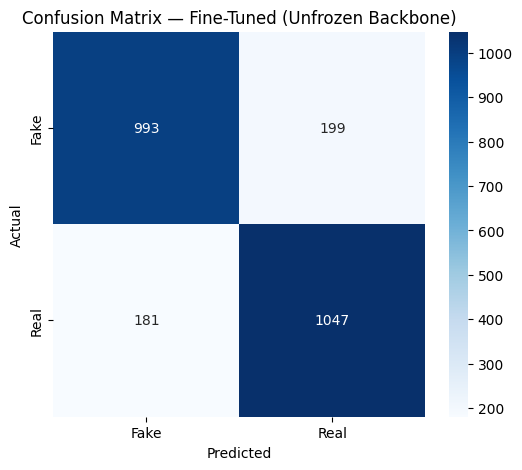


Done! Compare this with your frozen-backbone results.


In [ ]:
############################################################
# UNFROZEN BACKBONE — FULL FINE-TUNING 
############################################################

import torch
from torch import nn
import numpy as np
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# Unfreeze backbone
# =====================
print("Unfreezing entire ViT backbone...")
for param in model.parameters():
    param.requires_grad = True

# ====================================
# Define optimizer for full model
# ====================================
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

fine_tune_epochs = 2
model.to(device)

# =============================
# Fine-tuning training loop
# =============================
print("\n=== Training UNFROZEN backbone (fine-tuning) ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    for batch in tqdm(dataloader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples * 100
    print(f"Fine-Tune Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")


# ============================
# Evaluate fine-tuned model
# ============================
print("\n=== Evaluating fine-tuned model ===")

model.eval()
all_labels_ft = []
all_preds_ft = []
all_probs_ft = []
eval_loss = 0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels_ft.extend(labels.cpu().numpy())
        all_preds_ft.extend(preds.cpu().numpy())
        all_probs_ft.extend(probs.cpu().numpy())

avg_loss = eval_loss / total_samples
acc = accuracy_score(all_labels_ft, all_preds_ft)

cm = confusion_matrix(all_labels_ft, all_preds_ft)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
ppv = tp / (tp + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print("\n=== Fine-Tuned Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"PPV: {ppv:.2f}")
print(f"NPV: {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")
print("Classification Report:")
print(classification_report(all_labels_ft, all_preds_ft, digits=4))


# ====================
# Confusion Matrix
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned (Unfrozen Backbone)")
plt.show()

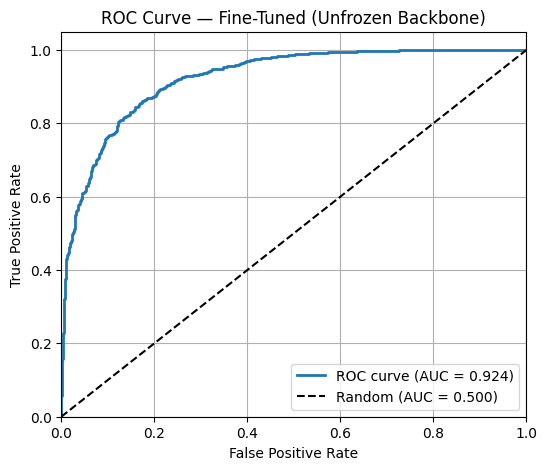

In [12]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

fpr_ft, tpr_ft, _ = roc_curve(all_labels_ft, all_probs_ft)
roc_auc_ft = auc(fpr_ft, tpr_ft)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ft, tpr_ft, label=f"ROC curve (AUC = {roc_auc_ft:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned (Unfrozen Backbone)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [7]:
num_ftrs = model.num_features

model.head = nn.Sequential(
    nn.LayerNorm(num_ftrs),     # normalize ViT features
    nn.Linear(num_ftrs, 512),
    nn.GELU(),                  # smoother than ReLU, standard in transformers
    nn.Dropout(0.3),

    nn.Linear(512, 128),
    nn.GELU(),
    nn.Dropout(0.2),

    nn.Linear(128, 2)           # final logits: [real, fake]
)

In [10]:
# =====================
# Unfreeze entire model
# =====================
for param in model.parameters():
    param.requires_grad = True

# Separate backbone vs head params for different learning rates
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if "head" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

from torch.optim import AdamW
from torch import nn

# Smaller LR for pretrained backbone, larger for new head
optimizer = AdamW(
    [
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params, "lr": 5e-5},
    ],
    weight_decay=1e-4
)

# Label smoothing helps generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

fine_tune_epochs = 2


In [14]:
from tqdm import tqdm
import torch

print("\n=== Training UNFROZEN backbone with new head ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    for batch in tqdm(dataloader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping: prevent crazy updates
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples * 100
    print(f"Fine-Tune Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")



=== Training UNFROZEN backbone with new head ===

Epoch 1/2


100%|██████████| 255/255 [14:27<00:00,  3.40s/it]


Fine-Tune Loss: 0.5952, Acc: 70.92%

Epoch 2/2


100%|██████████| 255/255 [14:06<00:00,  3.32s/it]

Fine-Tune Loss: 0.4213, Acc: 85.83%



=== Evaluating Fine-Tuned Model ===


100%|██████████| 152/152 [03:39<00:00,  1.44s/it]



=== Fine-Tuned Results ===
Accuracy: 82.64%
Sensitivity: 0.90
Specificity: 0.75
PPV: 0.79
NPV: 0.88
Average Loss: 0.4683

Classification Report:
              precision    recall  f1-score   support

           0     0.8792    0.7508    0.8100      1192
           1     0.7882    0.8998    0.8403      1228

    accuracy                         0.8264      2420
   macro avg     0.8337    0.8253    0.8251      2420
weighted avg     0.8330    0.8264    0.8254      2420



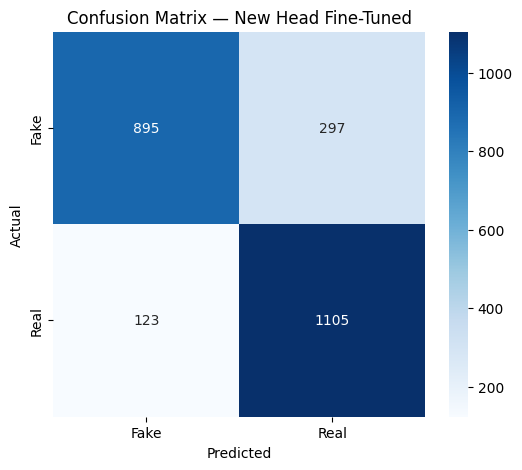

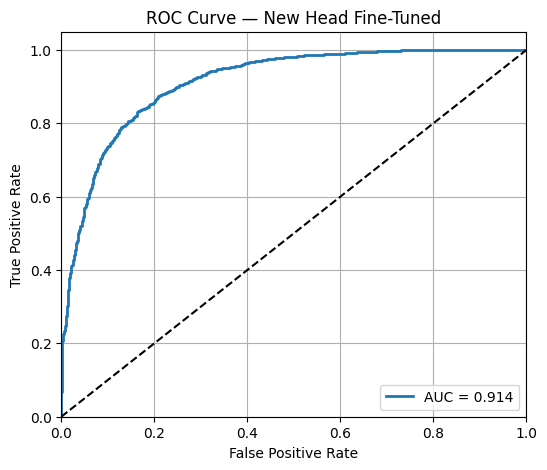

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import torch

print("\n=== Evaluating Fine-Tuned Model ===")

model.eval()
all_labels = []
all_preds = []
all_probs = []
eval_loss = 0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

avg_loss = eval_loss / total_samples
acc = accuracy_score(all_labels, all_preds)

# Confusion matrix + derived stats
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
ppv = tp / (tp + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print("\n=== Fine-Tuned Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"PPV: {ppv:.2f}")
print(f"NPV: {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — New Head Fine-Tuned")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — New Head Fine-Tuned")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Training and Evaluation Complete - Helper Functions Below**

In [ ]:
# HELPER: Unify model outputs
# Use this function to extract logits consistently from DeiT distilled models.
import torch

def get_deit_logits(outputs, distill_mode: str = "avg"):
    """
    DeiT distilled models may return:
      - Tensor logits
      - Tuple(logits, logits_distill)
      - ModelOutput with .logits and maybe .logits_distill

    distill_mode:
      - "logits": use primary logits
      - "distill": use distillation logits
      - "avg": average both (default)
    """
    # case 1: huggingface ModelOutput
    if hasattr(outputs, "logits"):
        logits = outputs.logits
        logits_distill = getattr(outputs, "logits_distill", None)
    # case 2: tuple
    elif isinstance(outputs, (tuple, list)) and len(outputs) >= 2:
        logits, logits_distill = outputs[0], outputs[1]
    # case 3: raw tensor
    else:
        logits, logits_distill = outputs, None

    if logits_distill is None:
        return logits

    if distill_mode == "logits":
        return logits
    if distill_mode == "distill":
        return logits_distill
    # default: avg
    return 0.5 * (logits + logits_distill)

In [ ]:
# EXPORT: Save weights and metadata
# This cell saves the model state_dict, config.json, and processor to a local folder.
import os, json, torch

EXPORT_DIR = "export/deit-distilled"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save weights (state_dict)
torch.save(model.state_dict(), os.path.join(EXPORT_DIR, "model.pth"))

# Preprocess details (MUST match training)
preprocess = {
    "input_size": 224,
    "resize": 256,
    "center_crop": True,
    "interpolation": "bicubic",
    "normalize": {
        "mean": [0.5, 0.5, 0.5],
        "std":  [0.5, 0.5, 0.5]
    }
}

label_map = {"0": "real", "1": "fake"}

# Distill output handling (must match helper above)
config = {
    "name": "deit-distilled",
    "framework": "pytorch",
    "arch": "deit_base_distilled_patch16_224",
    "patch_size": 16,
    "num_classes": 2,
    "threshold": 0.50,
    "labels": label_map,

    # CRITICAL: how to combine tuple logits
    # allowed: "logits", "distill", "avg"
    "distill_logits_mode": "avg",

    "notes": "DeiT distilled transfer model for deepfake detection"
}

with open(os.path.join(EXPORT_DIR, "preprocess.json"), "w") as f:
    json.dump(preprocess, f, indent=2)

with open(os.path.join(EXPORT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

with open(os.path.join(EXPORT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

readme = """---
license: apache-2.0
tags:
  - deit
  - vision-transformer
  - deepfake-detection
  - image-classification
---

# DeiT Distilled – DeepFakeDetector

DeiT distilled (base) fine-tuned for binary deepfake detection.

## Labels
- 0 = real
- 1 = fake

## Distilled Output Handling
Some DeiT distilled implementations return two logits tensors:
- primary logits
- distillation logits

This repo stores `distill_logits_mode` in config.json (default: avg).
"""

with open(os.path.join(EXPORT_DIR, "README.md"), "w") as f:
    f.write(readme)

print("Exported DeiT distilled artifacts to:", EXPORT_DIR)

In [ ]:
# UPLOAD: Push artifacts to Hugging Face
# Requirement: Make sure you have run !huggingface-cli login with a 'Write' token.
import os
from huggingface_hub import HfApi

REPO_ID = "DeepFakeDetector/deit-distilled"
HF_TOKEN = os.environ.get("HF_TOKEN_WRITE")
assert HF_TOKEN, "HF_TOKEN_WRITE env var not set."

api = HfApi(token=HF_TOKEN)

# Create repo if it doesn't exist
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path=EXPORT_DIR,
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="Upload DeiT distilled artifacts (weights + configs + preprocess)"
)

print(f"Uploaded to https://huggingface.co/{REPO_ID}")

In [ ]:
# VERIFY: Test loading the exported config
# Run this cell to ensure your config.json is valid and loadable via Transformers.
import torch
from huggingface_hub import snapshot_download

local_repo = snapshot_download(repo_id=REPO_ID, repo_type="model")

state = torch.load(os.path.join(local_repo, "model.pth"), map_location="cpu")
model.load_state_dict(state)
model.eval()

print("DeiT distilled weights reloaded successfully from HF")